In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df=pd.read_csv('Telco.csv')

In [3]:
pd.set_option('display.max_columns' , None) # used for displaying max columns
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Getting Basic info of the Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
print(df["TotalCharges"].dtype)

# Show values that cannot be converted
mask = pd.to_numeric(df["TotalCharges"], errors="coerce").isna()
print(df.loc[mask, "TotalCharges"])

object
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object


In [7]:
df.drop(index=[488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], inplace=True)

In [8]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [9]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0:'No' , 1 : 'Yes'})

In [10]:
df['MonthlySpentCategory']=1

In [11]:
def mc(x):
    if x<40:
        return 'Low'
    elif x<70 :
        return 'Medium'
    elif x<90:
        return 'High'
    else :
        return 'Very High'

In [12]:
df['MonthlySpentCategory']=df['MonthlyCharges'].apply(mc)

In [13]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlySpentCategory
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Medium
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,High
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,Very High
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Low
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,High


In [14]:
def tenure_group(x):
    if x <= 12:
        return "New"
    elif x <= 24:
        return "Short-term"
    elif x <= 48:
        return "Mid-term"
    elif x <= 60:
        return "Long-term"
    else:
        return "Loyal"

In [15]:
df['TenureGroup']=df['tenure'].apply(tenure_group) #No loop required here.

In [16]:
df["AvgCharge"] = df["TotalCharges"]/(df["tenure"])

In [17]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,MonthlySpentCategory,TenureGroup,AvgCharge
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Low,New,29.850000
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,Medium,Mid-term,55.573529
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Medium,New,54.075000
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Medium,Mid-term,40.905556
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,High,New,75.825000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,High,Short-term,82.937500
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,Very High,Loyal,102.262500
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,Low,New,31.495455
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,High,New,76.650000


# Business Related Questions

# Churned Percentage

In [18]:
group1=df.groupby('Churn').size().reset_index()
group1

,Churn,0
0,No,5163
1,Yes,1869


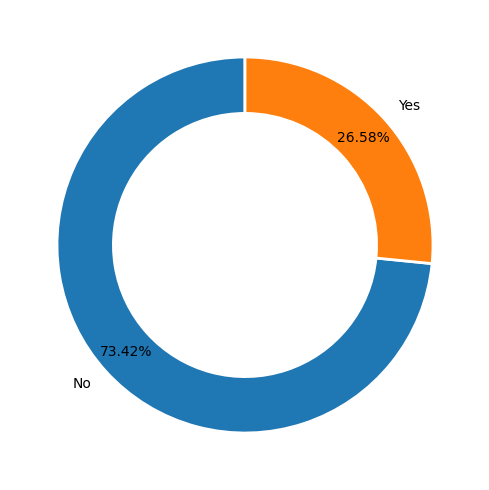

In [19]:
plt.figure(figsize=(7,5))


labels = ['No' , 'Yes']
plt.pie(group1[0],labels=labels,autopct='%1.2f%%' , startangle=90, pctdistance=0.85, wedgeprops={'width': 0.3, 'edgecolor': 'white', 'linewidth': 2})


plt.tight_layout()
plt.show()

# Distribution Of Customer By Gender

In [20]:
group2=df.groupby('gender').size().reset_index()
group2

,gender,0
0,Female,3483
1,Male,3549


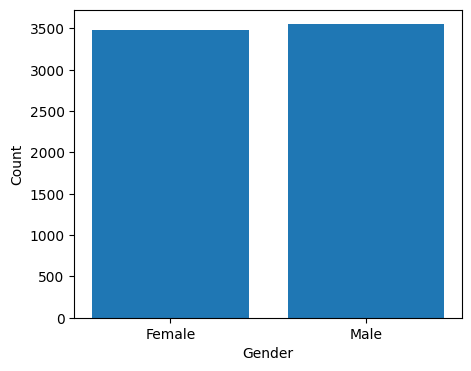

In [21]:

plt.figure(figsize=(5,4))
plt.bar(group2['gender'] , group2[0] )

plt.xlabel('Gender')
plt.ylabel('Count')


plt.show()

# Churn Between Male and Female 

In [22]:
group3=df.groupby(['gender' , 'Churn']).size().reset_index()
group3

,gender,Churn,0
0,Female,No,2544
1,Female,Yes,939
2,Male,No,2619
3,Male,Yes,930


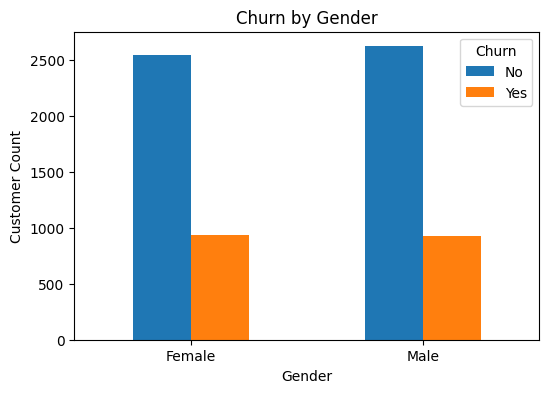

In [23]:


pivot = group3.pivot(index='gender', columns='Churn', values=0)

pivot.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Churn by Contract Type

In [24]:
group5=df.groupby(['Contract' , 'Churn']).size().reset_index(name='Count')

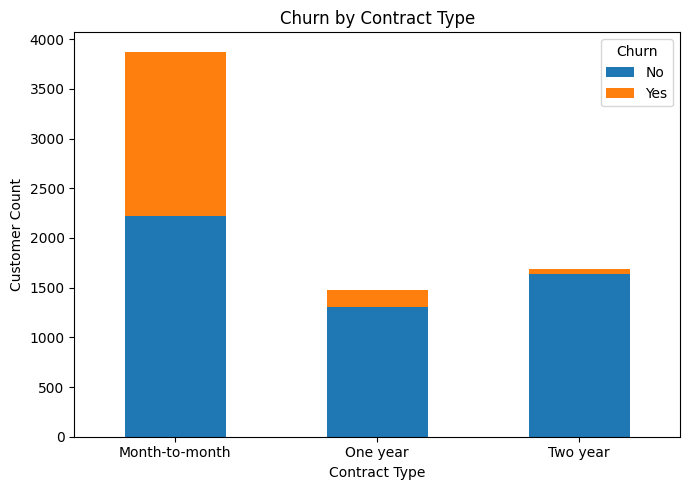

In [25]:

pivot = group5.pivot(index='Contract', columns='Churn', values='Count')

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# How does churn vary across tenure groups?

In [26]:
group4=df.groupby(['TenureGroup' , 'Churn']).size().reset_index(name='Count')

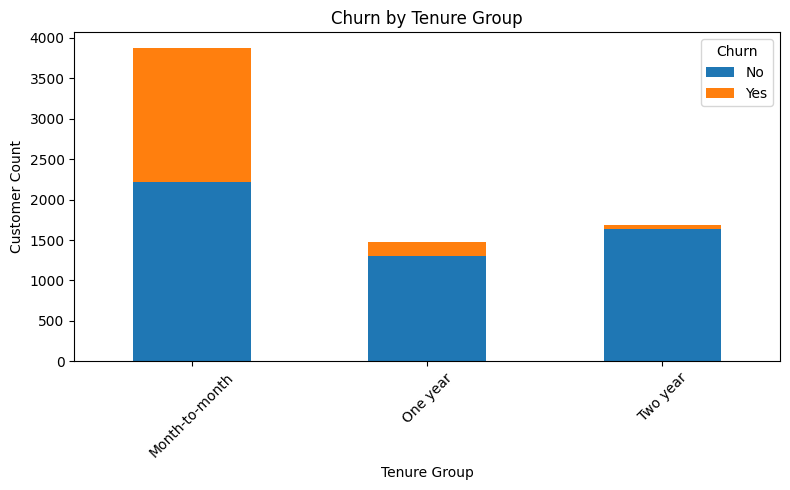

In [27]:



pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# Are senior citizens more likely to churn?

In [28]:
group6=df.groupby(['SeniorCitizen' , 'Churn']).size().reset_index(name='Count')

In [29]:
group6

,SeniorCitizen,Churn,Count
0,No,No,4497
1,No,Yes,1393
2,Yes,No,666
3,Yes,Yes,476


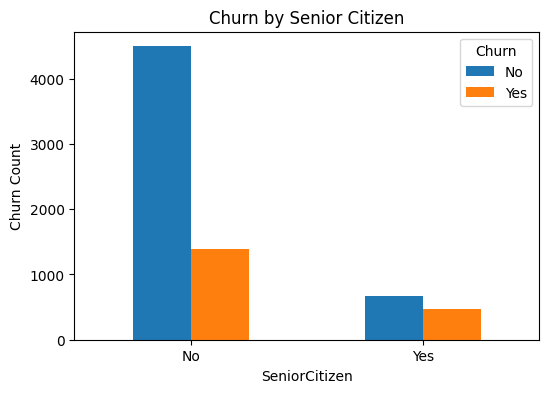

In [30]:
pivot = group6.pivot(index='SeniorCitizen', columns='Churn', values='Count')
pivot.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Senior Citizen")
plt.xlabel("SeniorCitizen")
plt.ylabel('Churn Count')

plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Do customers with partners churn less?

In [31]:
group7=df.groupby(['Partner' , 'Churn']).size().reset_index(name='Count')

In [32]:
group7

,Partner,Churn,Count
0,No,No,2439
1,No,Yes,1200
2,Yes,No,2724
3,Yes,Yes,669


In [33]:
group7['Partner']=group7['Partner'].map({'No' : 'No-Partner' , 'Yes' : 'Have a Partner' })

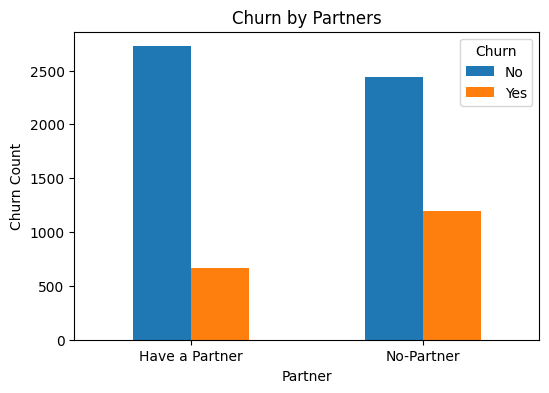

In [34]:
pivot = group7.pivot(index='Partner', columns='Churn', values='Count')
pivot.plot(kind='bar', figsize=(6,4))

plt.title("Churn by Partners")
plt.xlabel("Partner")
plt.ylabel('Churn Count')

plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

# Which tenure group has the most customers?

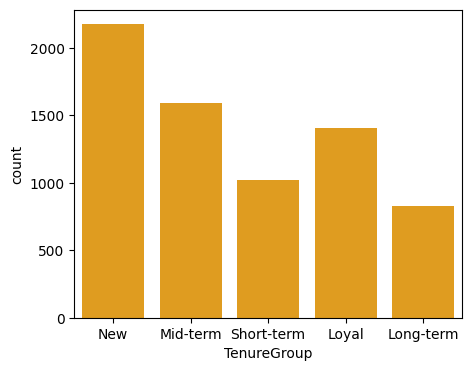

In [35]:
plt.figure(figsize=(5,4))
sns.countplot(data=df , x='TenureGroup' , color='Orange')
plt.show()

# Which Monthly Charges Category has the most customers?

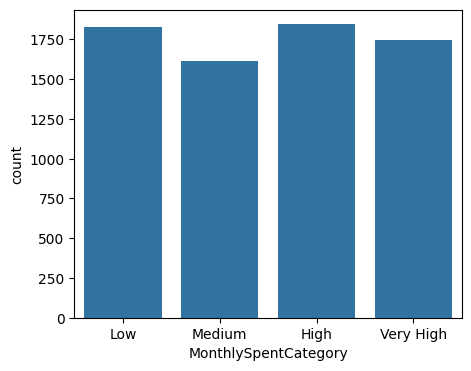

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(data=df , x='MonthlySpentCategory' )
plt.show()

# Which internet service has the highest churn?

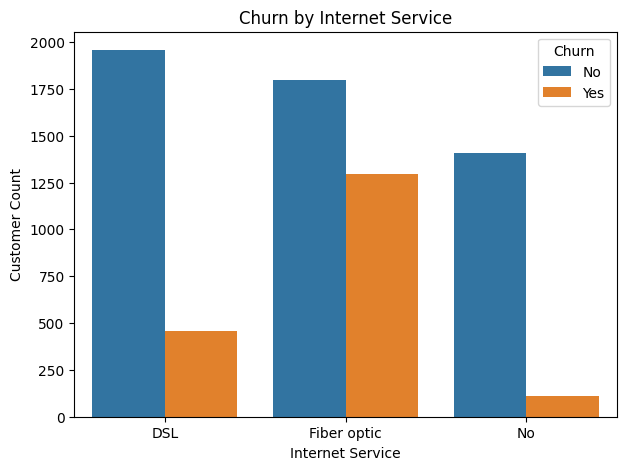

In [37]:


plt.figure(figsize=(7,5))
sns.countplot(data=df, x='InternetService', hue='Churn')

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Customer Count")
plt.legend(title="Churn")
plt.show()

# Does Device Protection affect churn?

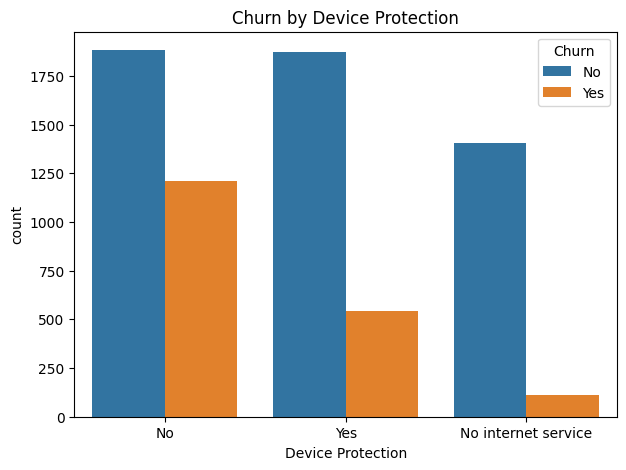

In [38]:

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='DeviceProtection', hue='Churn')
plt.title("Churn by Device Protection")
plt.xlabel("Device Protection")
plt.show()

# How are Monthly Charges distributed?

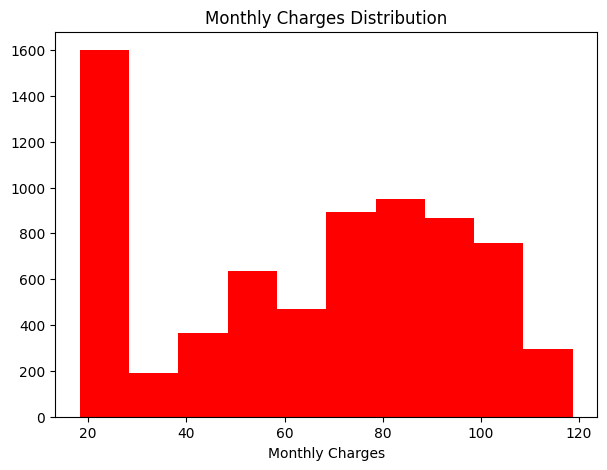

In [39]:
plt.figure(figsize=(7,5))
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.hist(df['MonthlyCharges'] , color='Red')
plt.show()


# What are the correlations among numerical features?

In [40]:
numeric_df = df[[ 'tenure', 'MonthlyCharges', 'TotalCharges' , ]]

In [41]:
corr = numeric_df.corr()

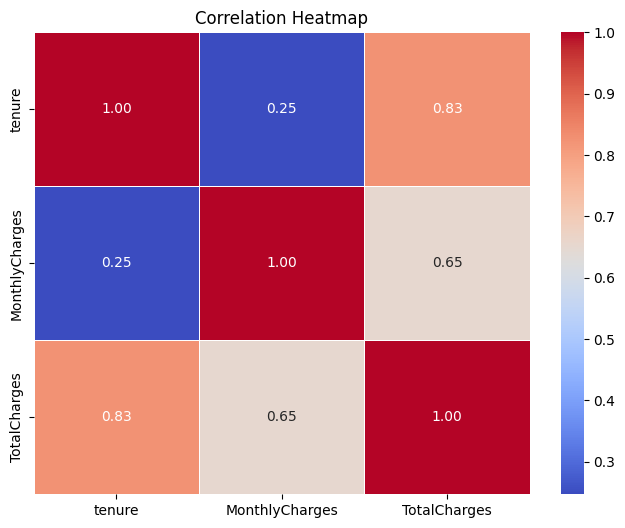

In [42]:


plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# Machine Learning

In [43]:
mldata=df

In [44]:
mldata.drop('customerID', axis=1 , inplace=True)

In [45]:
X=mldata.drop('Churn', axis=1)

In [46]:
y=mldata['Churn']

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,--
    random_state=42,
    stratify=y
)

In [49]:
cat_cols = X_train.select_dtypes(include='object').columns
num_cols = X_train.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

Categorical Columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlySpentCategory',
       'TenureGroup'],
      dtype='object')

Numerical Columns:
Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgCharge'], dtype='object')


In [50]:
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()

y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)  #LabelEncode the Churn(y)

In [51]:
df['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [52]:
df['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [53]:
df['TenureGroup'].unique()

array(['New', 'Mid-term', 'Short-term', 'Loyal', 'Long-term'],
      dtype=object)

In [54]:
binary_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]#type->list.

In [55]:
multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
    'MonthlySpentCategory',
    'TenureGroup'
] #type->list.

In [56]:


le = LabelEncoder()

for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [57]:
X_train = pd.get_dummies(
    X_train,
    columns=multi_cols,
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=multi_cols,
    drop_first=True,
    dtype=int
) #One Hot Encoding .

In [58]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,AvgCharge,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MonthlySpentCategory_Low,MonthlySpentCategory_Medium,MonthlySpentCategory_Very High,TenureGroup_Loyal,TenureGroup_Mid-term,TenureGroup_New,TenureGroup_Short-term
1413,1,0,1,1,65,1,0,94.55,6078.75,93.519231,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0
7003,1,0,0,0,26,0,0,35.75,1022.50,39.326923,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0
3355,0,0,1,0,68,1,0,90.20,6297.65,92.612500,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,1,1,0,0,0
4494,1,0,0,0,3,1,0,84.30,235.05,78.350000,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0
3541,0,0,1,0,49,0,0,40.65,2070.75,42.260204,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451,1,1,1,0,65,1,1,70.95,4555.20,70.080000,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
5123,0,1,0,0,15,1,1,75.30,1147.45,76.496667,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
4135,0,0,1,1,36,1,1,92.90,3379.25,93.868056,0,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1,0,0,0,0,1,0,1,0,0
4249,0,0,1,1,10,1,1,65.90,660.05,66.005000,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,0,1,0


In [59]:
print(X_train.shape)
print(X_test.shape)


(5625, 38)
(1407, 38)


In [60]:
X_train = X_train.drop(columns='AvgCharge')
X_test = X_test.drop(columns='AvgCharge')

In [61]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

# Applying Decision tree and Random Forest


In [62]:
from sklearn.tree import DecisionTreeClassifier

In [63]:
model_DT=DecisionTreeClassifier(random_state=42)

In [64]:
model_DT.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
DT_pred=model_DT.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [67]:
accuracy_score(y_test , DT_pred)

0.7100213219616205

In [68]:
confusion_matrix(y_test , DT_pred)

array([[825, 208],
       [200, 174]])

In [69]:
print(classification_report(y_test , DT_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1033
           1       0.46      0.47      0.46       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407



In [70]:
le_y.classes_ #No->0 , yes->1 ( it gives in alphabatical order)

array(['No', 'Yes'], dtype=object)

In [71]:
from sklearn.ensemble import RandomForestClassifier 

In [72]:
model_RF=RandomForestClassifier(n_estimators=100 , random_state=42) 

In [73]:
model_RF.fit(X_train , y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
RF_pred=model_DT.predict(X_test)

In [75]:
accuracy_score(y_test , RF_pred)

0.7100213219616205

In [76]:
confusion_matrix(y_test , RF_pred)

array([[825, 208],
       [200, 174]])

In [77]:
print(classification_report(y_test , RF_pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1033
           1       0.46      0.47      0.46       374

    accuracy                           0.71      1407
   macro avg       0.63      0.63      0.63      1407
weighted avg       0.71      0.71      0.71      1407



# Naive Bayes

In [78]:
from sklearn.naive_bayes import GaussianNB

In [79]:
model_NB=GaussianNB()

In [80]:
model_NB.fit(X_train , y_train)

,priors,None
,var_smoothing,1e-09


In [81]:
NB_pred=model_NB.predict(X_test)

In [82]:
accuracy_score(y_test , NB_pred)

0.6595593461265103

In [83]:
confusion_matrix(y_test , NB_pred)

array([[610, 423],
       [ 56, 318]])

In [84]:
print(classification_report(y_test , NB_pred))

              precision    recall  f1-score   support

           0       0.92      0.59      0.72      1033
           1       0.43      0.85      0.57       374

    accuracy                           0.66      1407
   macro avg       0.67      0.72      0.64      1407
weighted avg       0.79      0.66      0.68      1407



# KNN and Logistic Regression

In [85]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [86]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train_scaled[num_cols] = scaler.fit_transform(X_train_scaled[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_scaled[num_cols])

#or we can do :
# X_train_scaled['tenure'] = scaler.fit_transform(X_train_scaled[['tenure']])   .StandardScaler expects a 2D input like in fitting ,X expects a 2D amd in prediction also ,model.predict expects 2D

In [87]:
from sklearn.linear_model import LogisticRegression

In [88]:
model_LR=LogisticRegression()

In [89]:
model_LR.fit(X_train_scaled , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [90]:
LR_pred=model_LR.predict(X_test_scaled)

In [91]:
accuracy_score(y_test , LR_pred)

0.7945984363894811

In [92]:
confusion_matrix(y_test , LR_pred)

array([[921, 112],
       [177, 197]])

In [93]:
print(classification_report(y_test , LR_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407



In [94]:
from sklearn.neighbors import KNeighborsClassifier

In [95]:
model_KNN=KNeighborsClassifier(n_neighbors=5)

In [96]:
model_KNN.fit(X_train_scaled , y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [97]:
KNN_pred=model_KNN.predict(X_test_scaled)

In [98]:
accuracy_score(y_test , KNN_pred)

0.7647476901208244

In [99]:
confusion_matrix(y_test , KNN_pred)

array([[866, 167],
       [164, 210]])

In [100]:
print(classification_report(y_test , KNN_pred))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.56      0.56      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.77      1407



In [101]:
model_KNN2=KNeighborsClassifier(n_neighbors=15)

In [102]:
model_KNN2.fit(X_train_scaled , y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [103]:
KNN_pred2=model_KNN2.predict(X_test_scaled)

In [104]:
accuracy_score(y_test , KNN_pred2)

0.7818052594171997

In [105]:
confusion_matrix(y_test , KNN_pred2)

array([[890, 143],
       [164, 210]])

In [106]:
print(classification_report(y_test , KNN_pred2))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.56      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.72      1407
weighted avg       0.78      0.78      0.78      1407



# XGBoost

In [107]:

from xgboost import XGBClassifier

In [108]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

In [109]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [110]:
y_pred_xgb = xgb.predict(X_test)

In [111]:
accuracy_score(y_test , y_pred_xgb)

0.7953091684434968

In [112]:
print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))




Classification Report
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [113]:

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))


Confusion Matrix
[[919 114]
 [174 200]]


# Conclusion

### Made Various Models for prediction on Customer Churn

### XGBoost and Logistic Regression were the top model with good accuracy and classification_reports


### Precision , f1_score and recall for 0 ( Not Churn) was higher than 1(Churn)

### This was mainly because of the dataset.Our dataset was having approx 73 percent data with Not churn and 26 percent data with Churn.So models not properly recognized the pattern of Churn properly

### But Logistic Regression and XGBoost relatively has good recall , f1_Score and precision for Churn overall

In [115]:
joblib.dump(model_LR, "lr_model.pkl")
joblib.dump(model_RF, "rf_model.pkl")
joblib.dump(xgb, "xgb_model.pkl")

['xgb_model.pkl']

In [116]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [117]:
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']